In <run_seqnmf_cuda>, batchsize=26189
In <reconstruct_padded>: batch_size=50
Cost at initialization = 31.7099
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 1 = 0.2083; total elapsed=1.27 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 2 = 0.1990; total elapsed=1.33 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 3 = 0.1940; total elapsed=1.39 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 4 = 0.1908; total elapsed=1.45 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 5 = 0.1885; total elapsed=1.51 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost after iteration 6 = 0.1867; total elapsed=1.67 sec
In <reconstruct_padded>: batch_size=50
In <reconstruct_padded>: batch_size=50
Cost aft

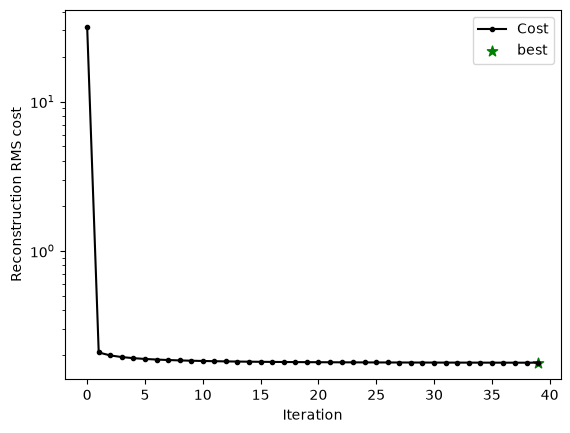

In [2]:
import sys
from collections import OrderedDict

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
sys.path.append("/home/sosalab/local_repos/seqnmf_cuda")
import seqnmf_cuda as seqnmf


BATCH_SIZE_IN_BYTES = (1<<32) # 4GB each batch
NUMPY_RNG_SEED = 41
CUPY_RNG_SEED = 41

# input data size; this example may not be large enough to demonstrate the
# accelaration from using GPU
N_CHANNELS = 500 # number of channels in data
N_SAMPLES  = 20000 # number of time points

K = 20 # number of kernels
L = 50 # length of kernel

# parameters of the SeqNMF algorithm itself
seqnmf_algo_params = OrderedDict(
    K=K,
    L=L,
    n_iter=100,
    lambda_=0.0001,
    lambdaOrthoW=0.005,
    lambdaOrthoH=0.005,
    lambdaL1H=0.005,
    shift=True,
    tol=0.0001
)
# miscellaneous parameters such as verbosity and batch size in #shifts (which
# overrules BATCH_SIZE_BYTES)
nmf_misc_kwargs={}

# set random seed and batch size (useful for limiting VRAM usage)
seqnmf.set_batch_size_bytes(BATCH_SIZE_IN_BYTES)
seqnmf.set_seed(NUMPY_RNG_SEED, CUPY_RNG_SEED)

# generate dummy data
rng = np.random.default_rng(NUMPY_RNG_SEED)
data = rng.random((N_CHANNELS, NUMPY_RNG_SEED))
data_gpu = cp.asarray(data) # copy data from host memory to vram
# run seqnmf CUDA
result_dict = seqnmf.run_seqnmf_cuda(data_gpu, seqnmf_algo_params, **nmf_misc_kwargs)

# get results from last iteration
W = result_dict["W_cuda"].get() # W has shape (L, N_channels, K) | copy from GPU to host memory
H = result_dict["H_cuda"].get() # H has shape (K, N_amples) | copy from GPU to host memory
# cost_history has shape (n_iters,);
# cost[0] is the cost of initial randomization.
# cost[1] is the cost after 1st randomization. ...
cost_history = result_dict["cost"]
# number of last iteration; if stopped early due to convergence, last_iter < n_iter
last_iter = result_dict["last_iter"]
# the iteration# with lowest cost
best_iter = result_dict["best_iter"]
best_W = result_dict["best_W_cuda"].get()
best_H = result_dict["best_H_cuda"].get()

plt.figure()
plt.plot(np.arange(last_iter+1), cost_history[:last_iter+1], color="k", marker=".", label="Cost")
plt.scatter([best_iter], [cost_history[best_iter]], color="g", marker="*", s=60, alpha=1, label="best")
plt.xlabel("Iteration")
plt.ylabel("Reconstruction RMS cost")
plt.legend()
plt.yscale("log")
plt.show()

In [3]:
data.shape

(500, 41)